In [1]:
from typing import List, Optional, Tuple

import hydra
import torch
import pytorch_lightning as pl
from omegaconf import DictConfig
from pytorch_lightning import Callback, LightningDataModule, LightningModule, Trainer
from pytorch_lightning.loggers import LightningLoggerBase
from models.module import PatchClassificationModule
from models.model import construct_PPNet
from models.push import push_prototypes
import json
import random
import netCDF4
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/home/ines/televit_xai/xai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input_vars = [
    'lst_day',
    'ndvi',
    'rel_hum',
    'ssrd',
    'sst',
    't2m_min',
    'tp',
    'vpd']


path = "/data/ines/positive_batches/test/"

#extran mean for normalisation
path_mean = "/data/ines/positive_batches/train/mean_std.json"
with open(path_mean, 'r') as json_file:
    mean_std_dict = json.load(json_file)


batch_files = [filename for filename in os.listdir(path) if filename.startswith('batch')]



In [3]:
last_checkpoint = os.path.join('/home/ines/televit_xai/results/final/push_best.pth')
#checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()


/tmp/ipykernel_3809211/127810214.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


In [4]:
def get_image_gt(file):
        inputs = []
        dataset = netCDF4.Dataset(path  + file, mode='r') 
        #dataset = netCDF4.Dataset("/data/ines/positive_batches/test/batch_0_1277.nc")
        for variable_name in input_vars:

            variable_data = dataset.variables[variable_name][:][0]

            variable_data  = (variable_data  - mean_std_dict[f'{variable_name}_mean'])/mean_std_dict[f'{variable_name}_std']
            variable_data = np.nan_to_num(variable_data, nan=-1)

            input = torch.tensor(variable_data)
            inputs.append(input)

        ground_truth = dataset.variables["gwis_ba"][:][0] 
        mask_nan = np.isnan(ground_truth)
        ground_truth = np.nan_to_num(ground_truth, nan=0)

        ground_truth = np.where(ground_truth != 0, 1, 0)
        ground_truth = np.where(mask_nan, np.nan, np.where(ground_truth!= 0, 1, 0))
        ground_truth = np.ma.masked_invalid(ground_truth)


        inputs_tensor = torch.stack(inputs)  # Stack the tensors in the list
        image = inputs_tensor.numpy()
        inputs_tensor = inputs_tensor.unsqueeze(0).cuda()

        return inputs_tensor, image, ground_truth

def get_similarity_pred(inputs_tensor, prototype_number):
    
        conv_features = ppnet.conv_features(inputs_tensor)
        logits, distance = ppnet.forward_from_conv_features(conv_features)

        logits = logits.permute(0, 3, 1, 2)
        logits = logits[0]

        pred = torch.argmax(logits, dim=0).cpu().detach().numpy()

        proto_dist_img_j = distance[0][prototype_number, :, :].cpu().detach().numpy()
        proto_act_img_j = (2-proto_dist_img_j)/2 #np.log((proto_dist_img_j + 1) / (proto_dist_img_j + +1e-4))#

        return pred, proto_act_img_j

def plot_input_heatmap(image,proto_act_img_j):
        cols = 4
        rows = 2
        fig, axs = plt.subplots(rows, cols+1, figsize=(16, 8))  # Create subplots (2x4 grid)
        for channel in range(len(input_vars)):
            row_idx = channel // cols
            col_idx = channel % cols

            # Create overlayed image (grayscale image + heatmap)
            im = axs[row_idx, col_idx].imshow(image[ channel, :, :], cmap='viridis')#, vmin = -2, vmax = 2)
            #axs[row_idx, col_idx].imshow(heatmap, alpha=0.3)

            # Plot the bounding box with red lines
            # axs[row_idx, col_idx].plot([rf_start_w_index, rf_start_w_index], [rf_start_h_index, rf_end_h_index],
            #                             [rf_end_w_index, rf_end_w_index], [rf_start_h_index, rf_end_h_index],
            #                             [rf_start_w_index, rf_end_w_index], [rf_start_h_index, rf_start_h_index],
            #                             [rf_start_w_index, rf_end_w_index], [rf_end_h_index, rf_end_h_index],
            #                             linewidth=2, color='red')
            axs[row_idx, col_idx].set_title(f"Channel {input_vars[channel]}")
            plt.colorbar(im, ax=axs[row_idx, col_idx], fraction=0.046, pad=0.04)
            axs[row_idx, col_idx].axis('off')


        im = axs[0,-1].imshow(proto_act_img_j)#, vmin = -0.5 , vmax=0.5)
        plt.colorbar(im, ax = axs[0,-1], fraction=0.046, pad=0.04)
        axs[0,-1].axis('off')
        axs[1,-1].axis('off')
        plt.tight_layout()

       



1638


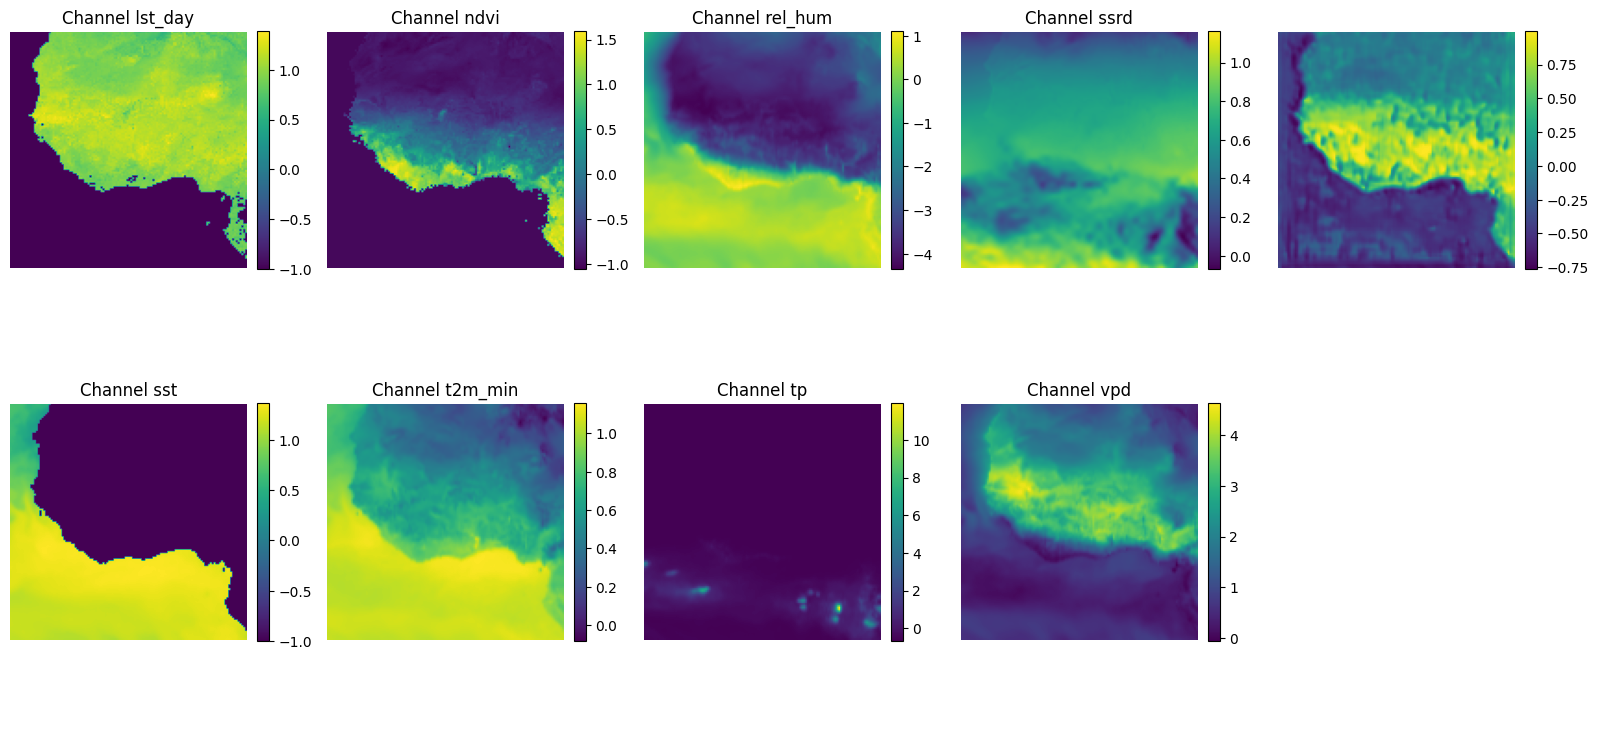

In [6]:
random_files = random.sample(batch_files, min(1, len(batch_files)))
world = [batch_files[0],batch_files[44],batch_files[91],batch_files[93],batch_files[107],batch_files[155],batch_files[181], batch_files[225]]

for file in [batch_files[181]]:
    inputs_tensor, image, ground_truth = get_image_gt(file)

    pred,proto_act_img_j = get_similarity_pred(inputs_tensor, 13)
    print((pred==1).sum())
    plot_input_heatmap(image,proto_act_img_j)




/tmp/ipykernel_3809211/1832697201.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


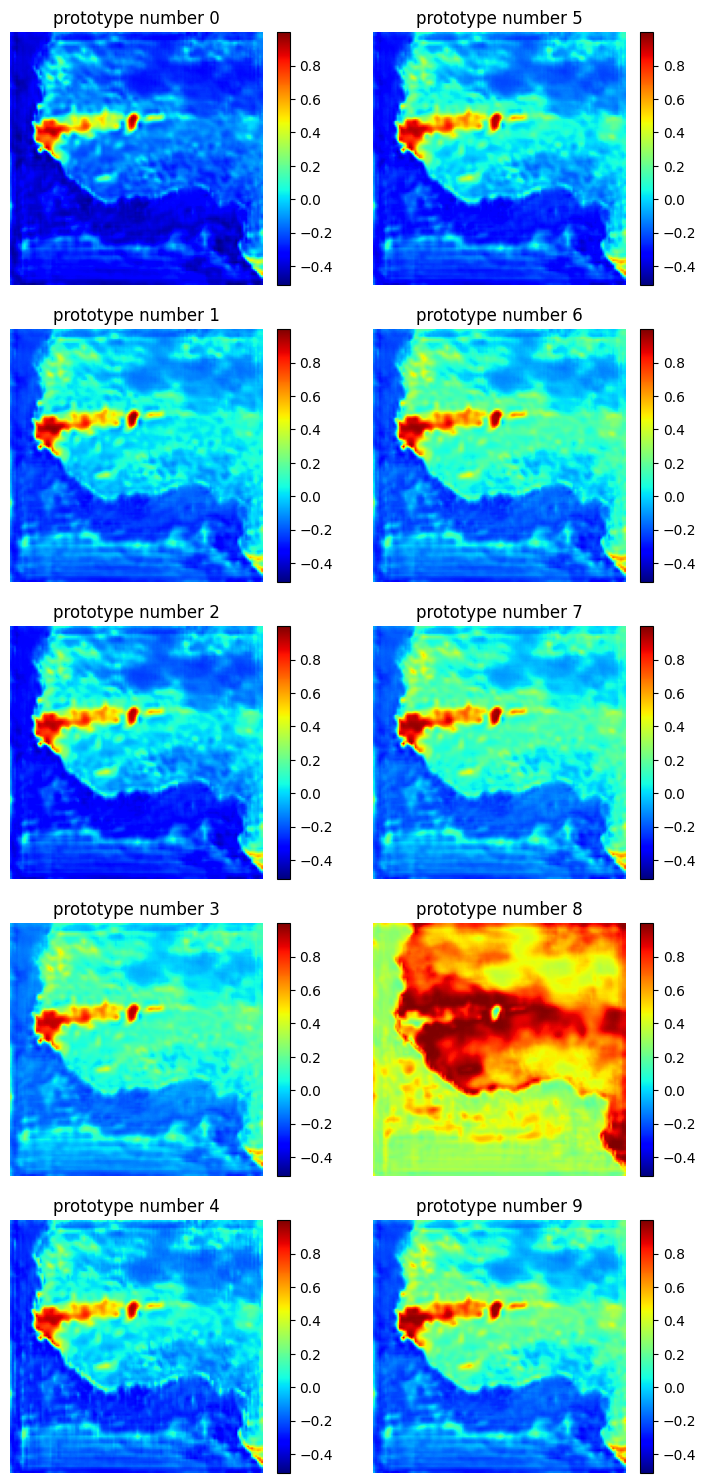

In [15]:
# Load the model from the last checkpoint
last_checkpoint = os.path.join('/home/ines/televit_xai/results/checkpoints/push_best.pth')
# checkpoint = torch.load('/home/ines/televit_xai/logs/train/runs/2024-11-14_20-06-56/checkpoints/epoch_013.ckpt')
if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()

# Randomly select files
random_files = random.sample(batch_files, min(1, len(batch_files)))
world = [batch_files[0], batch_files[44], batch_files[91], batch_files[93],
         batch_files[107], batch_files[155], batch_files[181], batch_files[225]]

# Set up the plot
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(8, 15))

# Get a consistent vmin and vmax
all_activations = []
for file in [batch_files[181]]:
    inputs_tensor, image, ground_truth = get_image_gt(file)
    for i in range(10):
        _, proto_act_img_j = get_similarity_pred(inputs_tensor, 10 + i)
        all_activations.append(proto_act_img_j)

vmin = min(act.min() for act in all_activations)
vmax = max(act.max() for act in all_activations)

# Plot the images with consistent vmin and vmax
for file in [batch_files[155]]:
    inputs_tensor, image, ground_truth = get_image_gt(file)
    for i in range(10):
        pred, proto_act_img_j = get_similarity_pred(inputs_tensor, 10 + i)
        im = axs[i % 5, i // 5].imshow(proto_act_img_j, vmin=vmin, vmax=vmax, cmap = 'jet')
        axs[i % 5, i // 5].axis('off')
        plt.colorbar(im, ax=axs[i % 5, i // 5], fraction=0.046, pad=0.04)
        axs[i % 5, i // 5].set_title('prototype number ' + str(i))

plt.tight_layout()
plt.show()


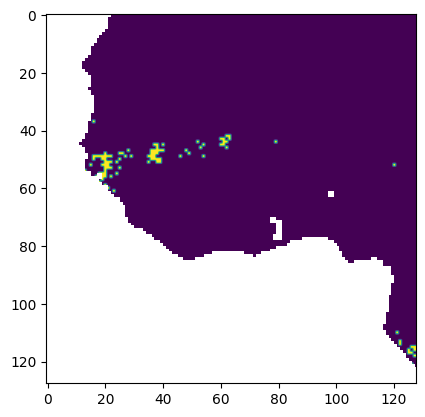

In [16]:
plt.imshow(ground_truth)